In [318]:
import matplotlib.pyplot as plt
from cycler import cycler

# Shared figure style. Run before the plotting cells.
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['STIXGeneral'],
    'mathtext.fontset': 'stix',
    'text.usetex': False,
    'font.size': 18,
    'axes.labelsize': 20,
    'axes.titlesize': 18,
    'xtick.labelsize': 18,
    'ytick.labelsize': 18,
    'legend.fontsize': 18,
    'legend.loc': 'lower right',
    'figure.figsize': (6, 5),
    'figure.autolayout': True,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.03,
    'axes.grid': False,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.prop_cycle': cycler(color=['#1f77b4', '#ff7f0e', '#289B78', '#8B5CB8']),
})

def style_graphics_figure():
    fig = plt.gcf()
    fig.set_size_inches(6, 5)
    for ax in fig.axes:
        ax.grid(False, which="both", axis="both")
        ax.spines[['top', 'right']].set_visible(False)
        ax.tick_params(labelsize=18)
        ax.xaxis.label.set_fontsize(20)
        ax.yaxis.label.set_fontsize(20)
        legend = ax.get_legend()
        if legend is not None:
            legend.set_loc('lower right')
            for text in legend.get_texts():
                text.set_fontsize(18)
            for handle in legend.get_lines():
                handle.set_linewidth(2)
                if handle.is_dashed():
                    handle.set_dashes((2, 2))
    fig.tight_layout()


In [319]:
from pathlib import Path
import sys

# Run this cell before importing utils, octopus, oracle, blackboxes, or front_utils.
project_dir = Path(r'\Cosmic Octopi')
candidates = [base / 'Cosmic Octopi' for base in (Path.cwd(), *Path.cwd().parents)]
candidates += [base / 'Cosmic Octopi' / 'Cosmic Octopi' for base in (Path.cwd(), *Path.cwd().parents)]
candidates.append(project_dir / 'Cosmic Octopi')
modules_dir = next((path for path in candidates if (path / 'utils.py').is_file()), None)
if modules_dir is None:
    raise FileNotFoundError(f'Cannot find Cosmic Octopi modules from {Path.cwd()}')
sys.path.insert(0, str(modules_dir.resolve()))
print(f'Importing local modules from: {modules_dir.resolve()}')


Importing local modules from: C:\Users\Mohamed2\Documents\Journal\Cosmic Octopi\Cosmic Octopi


In [320]:
from tqdm import trange
from utils import generate_global_iterations_instants_holistic
from utils import generate_global_iterations_instants_reductionist
from utils import generate_learning_periods
from utils import generate_triggering_events_instants
from utils import generate_diffusion_parameters
import utils
import octopus
import oracle
import importlib
import front_utils
import blackboxes
importlib.reload(utils)
importlib.reload(octopus)
importlib.reload(oracle)
importlib.reload(front_utils)
importlib.reload(blackboxes)

from oracle import Oracle
from octopus import Octopus
import numpy as np
import matplotlib.pyplot as plt

import copy

import pickle
import os

import torch

from pymle.sim.Simulator1D import Simulator1D
from pymle.models import OrnsteinUhlenbeck
import matplotlib.cm as cm
import matplotlib.colors as mcolors

from front_utils import expected_pareto_front, RTS_pareto_front, STR_pareto_front
from blackboxes import blackbox_reductionist, blackbox_holistic

from scipy.stats.qmc import Sobol

from pymle.fit.AnalyticalMLE import AnalyticalMLE
from pymle.core.TransitionDensity import EulerDensity
from sklearn.linear_model import LinearRegression

import subprocess

Using device: cuda
GPU: NVIDIA RTX A2000 8GB Laptop GPU
Using device: cuda
GPU: NVIDIA RTX A2000 8GB Laptop GPU
Using device: cuda
GPU: NVIDIA RTX A2000 8GB Laptop GPU
Using device: cuda
GPU: NVIDIA RTX A2000 8GB Laptop GPU
Using device: cuda
GPU: NVIDIA RTX A2000 8GB Laptop GPU
Using device: cuda
GPU: NVIDIA RTX A2000 8GB Laptop GPU


In [321]:
def load_object(remote_file_path, local_dir=".", key_filename=None, password=None):
    remote_user = "mohamedbellouch"
    remote_host = "138.195.36.204"   # replace with actual IP

    os.makedirs(local_dir, exist_ok=True)
    local_file = os.path.join(local_dir, os.path.basename(remote_file_path))

    # Build scp command
    cmd = ["scp", "-o", "StrictHostKeyChecking=no"]

    if key_filename:
        cmd.extend(["-i", key_filename])
    elif password:
        # Note: password auth with scp is not straightforward in subprocess.
        # Key-based authentication is strongly recommended.
        print("Warning: Password authentication is not supported in this version. Use SSH key instead.")
        return None

    cmd.extend([f"{remote_user}@{remote_host}:{remote_file_path}", local_file])

    # Execute scp
    try:
        subprocess.run(cmd, check=True, capture_output=True, text=True)
    except subprocess.CalledProcessError as e:
        print(f"Error during transfer: {e.stderr}")
        raise

    # Load the pickle file
    with open(local_file, "rb") as f:
        obj = pickle.load(f)

    return obj

In [322]:
def load_remote_text_file(remote_file_path, local_dir=".", key_filename="~/.ssh/id_rsa"):
    remote_user = "mohamedbellouch"
    remote_host = "138.195.36.204"   # ← replace with the actual IP address
    
    os.makedirs(local_dir, exist_ok=True)
    local_file = os.path.join(local_dir, os.path.basename(remote_file_path))
    
    # Download file using scp
    cmd = [
        "scp", "-o", "StrictHostKeyChecking=no", "-i", key_filename,
        f"{remote_user}@{remote_host}:{remote_file_path}", local_file
    ]
    
    subprocess.run(cmd, check=True, capture_output=True, text=True)
    
    # Read file and return list of lines
    with open(local_file, "r", encoding="utf-8") as f:
        lines = [line.rstrip("\n") for line in f.readlines()]
    
    return lines

In [323]:
def magic_function(init, mean_reversion, long_term, volatility, n):
    model = OrnsteinUhlenbeck()
    model.params = np.array([mean_reversion, long_term, volatility])
    simulator = Simulator1D(init, n, 1, model)
    rewards = simulator.sim_path().flatten()
    return rewards

## role of $\gamma_\text{heter}$ and $\gamma_\text{sync}$

Saved c:\Users\Mohamed2\Documents\Journal\Cosmic Octopi\Paper plots\low_heter_high_sync.pdf


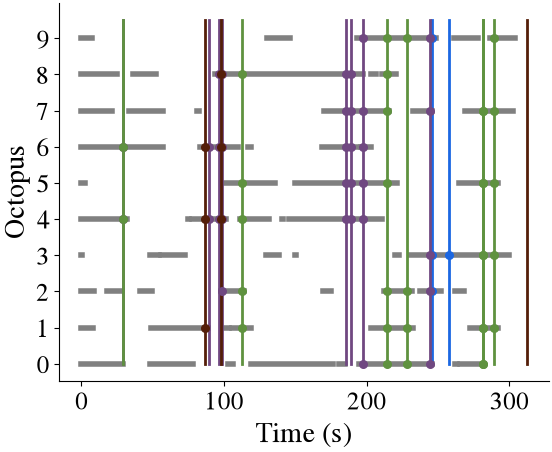

In [324]:
system_dynamics_params_ = {
    'n_octopi': 10,
    'n_classes': 4,
    'gamma_learn': 20,
    'gamma_break': 30,
    'gamma_req': 10,
    'gamma_heter': .1,
    'gamma_grav': .001,
    'gamma_sync': 1,
    'gamma_epis': 1,
    }

horizon = 20
global_iterations_instants, oracle_iterations, time_horizon = generate_global_iterations_instants_holistic(system_dynamics_params_, horizon)
activation_periods, _ = generate_learning_periods(system_dynamics_params_, time_horizon)
triggering_events_instants, number_of_episodes = generate_triggering_events_instants(system_dynamics_params_,
                                                                                        global_iterations_instants, activation_periods)
c = 0

class_colors = ["#1B67E2", "#704881", "#5F923F", "#541E09"]

fig = plt.figure(figsize=(6, 5))

max_display_Octopi = 10
for i in range(max_display_Octopi):
    for period in activation_periods[i]:
        plt.plot(period, (i, i), color = "grey", linewidth = 4)
    for c in range(4):
        for z in triggering_events_instants[i][c]:
            plt.scatter([z], [i], s = 30, color=class_colors[c], zorder = 3)

for c in range(4):
    for y in global_iterations_instants[c]:
        plt.plot([y]*2, [0, max_display_Octopi-.5], color=class_colors[c], alpha = 1, linewidth = 2, zorder = 2)

#plt.grid('---')
plt.xlabel('Time (s)', fontsize=20)
plt.ylabel('Octopus', fontsize=20)
plt.xticks(fontsize=18)
plt.yticks(range(10), fontsize=18)
style_graphics_figure()
from pathlib import Path
_plot_root = next(base for base in (Path.cwd(), *Path.cwd().parents)
                  if (base / 'Paper plots' / 'Graphics.ipynb').is_file())
pdf_path = _plot_root / 'Paper plots' / 'low_heter_high_sync.pdf'
fig.savefig(pdf_path, format='pdf')
print(f'Saved {pdf_path}')
plt.show()

Saved c:\Users\Mohamed2\Documents\Journal\Cosmic Octopi\Paper plots\high_heter_low_sync.pdf


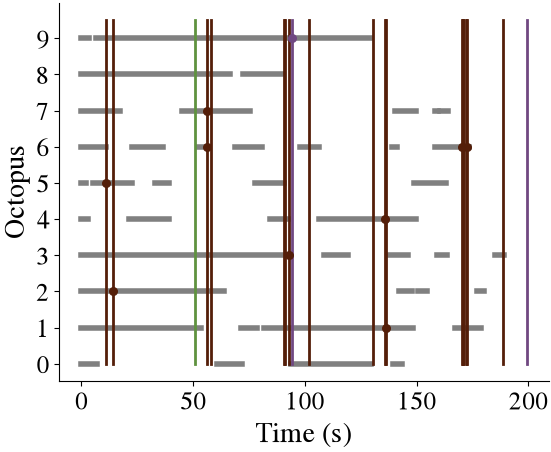

In [325]:
system_dynamics_params_ = {
    'n_octopi': 10,
    'n_classes': 4,
    'gamma_learn': 20,
    'gamma_break': 30,
    'gamma_req': 10,
    'gamma_heter': 8,
    'gamma_grav': .001,
    'gamma_sync': .2,
    'gamma_epis': 1,
    }

horizon = 20
global_iterations_instants, oracle_iterations, time_horizon = generate_global_iterations_instants_holistic(system_dynamics_params_, horizon)
activation_periods, _ = generate_learning_periods(system_dynamics_params_, time_horizon)
triggering_events_instants, number_of_episodes = generate_triggering_events_instants(system_dynamics_params_,
                                                                                        global_iterations_instants, activation_periods)

c = 0

class_colors = ["#1B67E2", "#704881", "#5F923F", "#541E09"]

fig = plt.figure(figsize=(6, 5))

max_display_Octopi = 10
for i in range(max_display_Octopi):
    for period in activation_periods[i]:
        plt.plot(period, (i, i), color = "grey", linewidth = 4)
    for c in range(4):
        for z in triggering_events_instants[i][c]:
            plt.scatter([z], [i], s = 30, color=class_colors[c], zorder = 3)

for c in range(4):
    for y in global_iterations_instants[c]:
        plt.plot([y]*2, [0, max_display_Octopi-.5], color=class_colors[c], alpha = 1, linewidth = 2, zorder = 2)

#plt.grid('---')

plt.xlabel('Time (s)', fontsize=20)
plt.ylabel('Octopus', fontsize=20)
plt.xticks(fontsize=18)
plt.yticks(range(10), fontsize=18)
style_graphics_figure()
from pathlib import Path
_plot_root = next(base for base in (Path.cwd(), *Path.cwd().parents)
                  if (base / 'Paper plots' / 'Graphics.ipynb').is_file())
pdf_path = _plot_root / 'Paper plots' / 'high_heter_low_sync.pdf'
fig.savefig(pdf_path, format='pdf')
print(f'Saved {pdf_path}')
plt.show()

## Role of $\gamma_\text{grav}$ and $M$

Saved c:\Users\Mohamed2\Documents\Journal\Cosmic Octopi\Paper plots\gravity_impact.pdf


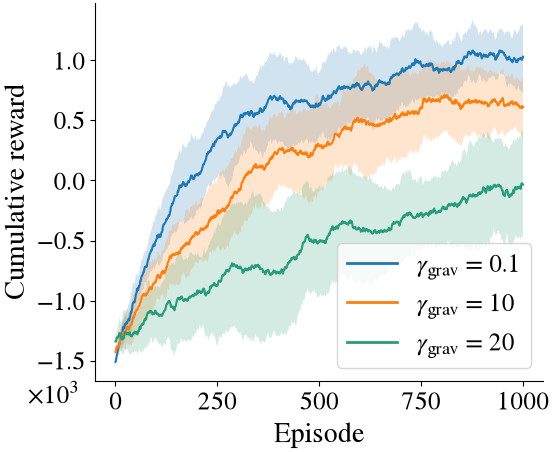

In [326]:
# Your data generation (unchanged)
leg_rewards_grav1 = np.array([magic_function(-1509, 5e-3, 1000, 30, 1000) for _ in range(10)])
leg_rewards_grav2 = np.array([magic_function(-1428, 3e-3, 950, 30, 1000) for _ in range(10)])
leg_rewards_grav3 = np.array([magic_function(-1339, 1e-3, 900, 30, 1000) for _ in range(10)])

fig = plt.figure(figsize=(6, 5))

for data, label in zip(
    [leg_rewards_grav1, leg_rewards_grav2, leg_rewards_grav3],
    [r'$\gamma_{\mathrm{grav}}$ = 0.1', r'$\gamma_{\mathrm{grav}}$ = 10', r'$\gamma_{\mathrm{grav}}$ = 20']
):
    mean = data.mean(axis=0)
    std = data.std(axis=0)
    x = np.arange(len(mean))

    plt.plot(x, mean, label=label)
    plt.fill_between(x, mean - std, mean + std, alpha=0.2)

plt.grid(False)
plt.xlabel("Episode", fontsize=20)
plt.ylabel("Cumulative reward", fontsize=20)
plt.legend(loc='lower right', fontsize=18)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

# Force y-axis to use scientific notation (numbers × 10^power)
# Force scientific notation on y-axis
ax = plt.gca()
ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0), useMathText=True)

# Hide the default offset text (the "× 10^power" at the top)
ax.yaxis.offsetText.set_visible(False)

# Add custom scientific notation text at the bottom-left
# Coordinates are in axes fraction: (0,0) is bottom-left corner of the plot area
ax.text(x=-.15, 
        y=0,                    # Adjust this value: more negative = lower
        s=r'$\times 10^{3}$',       # Change exponent if needed (Matplotlib usually chooses 3 here)
        transform=ax.transAxes, 
        fontsize=18,
        va='top',                   # Vertical alignment: 'top' keeps it above the line
        ha='left')                  # Horizontal alignment


plt.tight_layout()
style_graphics_figure()
from pathlib import Path
_plot_root = next(base for base in (Path.cwd(), *Path.cwd().parents)
                  if (base / 'Paper plots' / 'Graphics.ipynb').is_file())
pdf_path = _plot_root / 'Paper plots' / 'gravity_impact.pdf'
fig.savefig(pdf_path, format='pdf', bbox_inches='tight', pad_inches=0.03)
print(f'Saved {pdf_path}')
plt.show()

Saved c:\Users\Mohamed2\Documents\Journal\Cosmic Octopi\Paper plots\number_octopi_impact.pdf


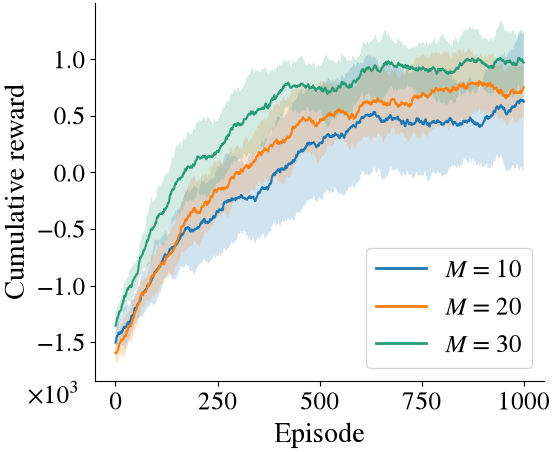

In [327]:
import numpy as np
import matplotlib.pyplot as plt

# Data generation
leg_rewards_grav1 = np.array([magic_function(-np.random.normal(1300, 100), 5e-3, 1000, 30, 1000) for _ in range(10)])
leg_rewards_grav2 = np.array([magic_function(-np.random.normal(1600, 100), 3e-3, 950, 30, 1000) for _ in range(10)])
leg_rewards_grav3 = np.array([magic_function(-np.random.normal(1500, 100), 2e-3, 900, 30, 1000) for _ in range(10)])

fig = plt.figure(figsize=(6, 5))

for data, label in zip(
    [leg_rewards_grav3, leg_rewards_grav2, leg_rewards_grav1],
    [r'$M$ = 10', r'$M$ = 20', r'$M$ = 30']
):
    mean = data.mean(axis=0)
    std = data.std(axis=0)
    x = np.arange(len(mean))

    plt.plot(x, mean, label=label)
    plt.fill_between(x, mean - std, mean + std, alpha=0.2)

plt.grid(False)
plt.xlabel("Episode", fontsize=20)
plt.ylabel("Cumulative reward", fontsize=20)
plt.legend(loc='lower right', fontsize=18)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

# Force scientific notation on y-axis
ax = plt.gca()
ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0), useMathText=True)

# Hide the default offset text (the "× 10^power" at the top)
ax.yaxis.offsetText.set_visible(False)

# Add custom scientific notation text at the bottom-left
# Coordinates are in axes fraction: (0,0) is bottom-left corner of the plot area
ax.text(x=-.15, 
        y=0,                    # Adjust this value: more negative = lower
        s=r'$\times 10^{3}$',       # Change exponent if needed (Matplotlib usually chooses 3 here)
        transform=ax.transAxes, 
        fontsize=18,
        va='top',                   # Vertical alignment: 'top' keeps it above the line
        ha='left')                  # Horizontal alignment


style_graphics_figure()
from pathlib import Path
_plot_root = next(base for base in (Path.cwd(), *Path.cwd().parents)
                  if (base / 'Paper plots' / 'Graphics.ipynb').is_file())
pdf_path = _plot_root / 'Paper plots' / 'number_octopi_impact.pdf'
fig.savefig(pdf_path, format='pdf', bbox_inches='tight', pad_inches=0.03)
print(f'Saved {pdf_path}')
plt.show()

## Role of the fitness margins

In [328]:
system_dynamics_params_ = {
    'n_octopi': 40,
    'n_classes': 4,
    'gamma_learn': 20,
    'gamma_break': 30,
    'gamma_req': 10,
    'gamma_heter': .001,
    'gamma_grav': .001,
    'gamma_sync': .9,
    'gamma_epis': 1,
    }

def blackbox(thresholds, system_dynamics_params_, diffusion_params_, hyper_params_, horizon):
    global_iterations_instants, oracle_iterations, time_horizon = generate_global_iterations_instants_reductionist(system_dynamics_params_, horizon)
    activation_periods, _ = generate_learning_periods(system_dynamics_params_, time_horizon)
    triggering_events_instants, number_of_episodes = generate_triggering_events_instants(system_dynamics_params_,
                                                                                        global_iterations_instants, activation_periods)
    overhead_increments_history = [[] for c in range(system_dynamics_params_['n_classes'])]
    instability_increments_history = [[] for c in range(system_dynamics_params_['n_classes'])]
    Observables = []
    gravities = np.random.normal(9.8, system_dynamics_params_['gamma_grav'], system_dynamics_params_['n_octopi'])
    Octopi = [Octopus(i, activation_periods[i],
                    triggering_events_instants[i],
                    number_of_episodes[i],
                    global_iterations_instants,
                    diffusion_params_[i],
                    hyper_params_,
                    gravities[i])
                    for i in range(system_dynamics_params_['n_octopi'])]
    galactic_oracle = Oracle(Octopi, system_dynamics_params_['n_classes'], global_iterations_instants, hyper_params_)
    for iteration in oracle_iterations:
        res = galactic_oracle.step(iteration[0], 
                                   iteration[1], 
                                   thresholds[iteration[0]][iteration[1]], 
                                   simulated_rewards=True,
                                   n_parallel=1)
        if res != None:
            overhead_increment, instability_increment = res[0], res[1]
            overhead_increments_history[iteration[0]].append(overhead_increment)
            instability_increments_history[iteration[0]].append(instability_increment)
        Observables.append([])

    overheads = [np.sum(ov_class[:-1]) for ov_class in overhead_increments_history]
    instabilities = [np.mean(inst_class[1:]) for inst_class in instability_increments_history]

    return (overheads, instabilities), galactic_oracle, Octopi

In [336]:
diffusion_params_ = generate_diffusion_parameters(system_dynamics_params_['n_octopi']) # the procedure
hyper_params_ = {'temperature': .001, 'scaling_constant': 1}
A = blackbox(0 + np.zeros((4, 10**5)), system_dynamics_params_, diffusion_params_, hyper_params_, 100)

Saved: c:\Users\Mohamed2\Documents\Journal\Cosmic Octopi\Paper plots\small_fitness_margin_results.pdf


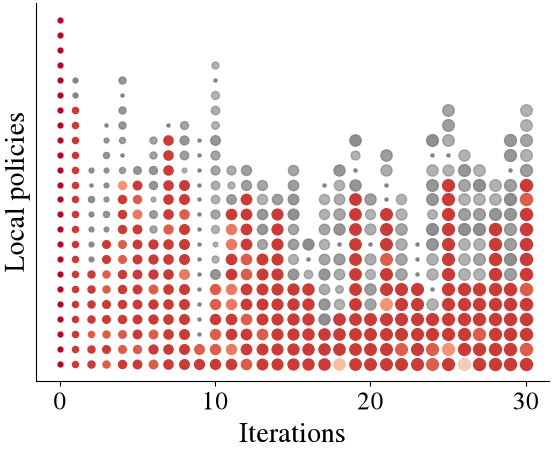

In [337]:
from pathlib import Path

fig = plt.figure(figsize=(6, 5))

Agg = A[1]
c = 2
display_horizon = 30

fitness_histories = [
    a.fitness_history[c][:display_horizon + 1]
    for a in Agg.octopi
    if len(a.fitness_history[c][:display_horizon + 1]) > 0
]

freshness_histories = [
    a.freshness_history[c][:display_horizon + 1]
    for a in Agg.octopi
    if len(a.freshness_history[c][:display_horizon + 1]) > 0
]

max_fitness = max(max(h) for h in fitness_histories)
min_fitness = min(min(h) for h in fitness_histories)

max_freshness = max(max(h) for h in freshness_histories)
min_freshness = min(min(h) for h in freshness_histories)

fitness_range = max_fitness - min_fitness
freshness_range = max_freshness - min_freshness

if fitness_range == 0:
    fitness_range = 1

if freshness_range == 0:
    freshness_range = 1

cmap = plt.get_cmap('coolwarm')  # blue → red

norm = mcolors.Normalize(
    vmin=min_freshness,
    vmax=max_freshness if max_freshness != min_freshness else min_freshness + 1
)

disc_size = 70

freshness_intensities = []

for i in range(
    min(len(Agg.contributing_octopi_history[c]), display_horizon + 1)
):
    contributing_Octopi = set(
        Agg.contributing_octopi_history[c][i]
    )

    candidate_Octopi_not_contributing = (
        set(Agg.candidate_octopi_history[c][i])
        - contributing_Octopi
    )

    active_Octopi_not_candidate = (
        set(Agg.active_octopi_history[c][i])
        - contributing_Octopi
        - candidate_Octopi_not_contributing
    )

    j = 0

    # plotting the contributing Octopi
    for a in contributing_Octopi:

        fitness_size = (
            disc_size
            * (a.fitness_history[c][i] - min_fitness)
            / fitness_range
            + 5
        )

        freshness_intensity = (
            a.freshness_history[c][i] - min_freshness
        ) / freshness_range

        color = cmap(norm(a.freshness_history[c][i]))

        plt.scatter(
            i,
            j,
            s=fitness_size,
            color=color
        )

        j += 1

    # plotting the candidate Octopi
    for a in candidate_Octopi_not_contributing:

        fitness_size = (
            disc_size
            * (a.fitness_history[c][i] - min_fitness)
            / fitness_range
            + 5
        )

        freshness_intensity = (
            a.freshness_history[c][i] - min_freshness
        ) / freshness_range

        freshness_intensity = max(freshness_intensity, 0.6)

        plt.scatter(
            i,
            j,
            s=fitness_size,
            alpha=freshness_intensity,
            color='grey'
        )

        j += 1

    for a in active_Octopi_not_candidate:

        fitness_size = max(a.fitness_history[c][i], 1)

        freshness_intensity = (
            a.freshness_history[c][i] - min_freshness
        ) / freshness_range

        j += 1


plt.xlabel("Iterations", fontsize=20)
plt.xticks(fontsize=18)
plt.yticks([], fontsize=18)

plt.ylabel("Local policies", fontsize=20)

style_graphics_figure()

# Save PDF in the current local folder
pdf_path = Path.cwd() / "small_fitness_margin_results.pdf"

fig.savefig(
    pdf_path,
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.03
)

print(f"Saved: {pdf_path}")

plt.show()

In [338]:
diffusion_params_ = generate_diffusion_parameters(system_dynamics_params_['n_octopi']) # the procedure
hyper_params_ = {'temperature': .001, 'scaling_constant': 1}
A = blackbox(10 + np.zeros((4, 10**5)), system_dynamics_params_, diffusion_params_, hyper_params_, 100)

Saved: c:\Users\Mohamed2\Documents\Journal\Cosmic Octopi\Paper plots\high_fitness_margin_results.pdf


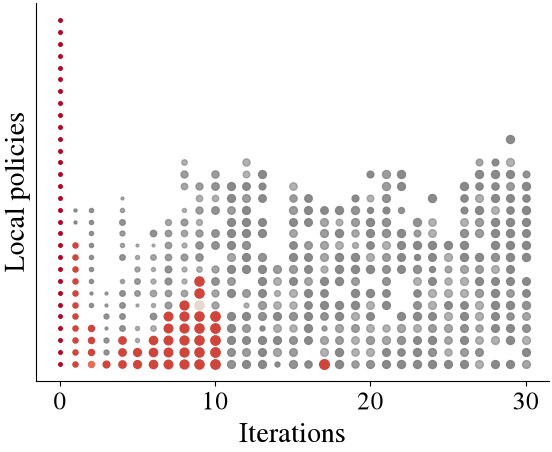

In [343]:
from pathlib import Path

fig = plt.figure(figsize=(6, 5))

Agg = A[1]
c = 2
display_horizon = 30

# Keep only non-empty histories
fitness_histories = [
    a.fitness_history[c][:display_horizon + 1]
    for a in Agg.octopi
    if len(a.fitness_history[c][:display_horizon + 1]) > 0
]

freshness_histories = [
    a.freshness_history[c][:display_horizon + 1]
    for a in Agg.octopi
    if len(a.freshness_history[c][:display_horizon + 1]) > 0
]

max_fitness = max(max(h) for h in fitness_histories)
min_fitness = min(min(h) for h in fitness_histories)

max_freshness = max(max(h) for h in freshness_histories)
min_freshness = min(min(h) for h in freshness_histories)

# Avoid division by zero
fitness_range = max_fitness - min_fitness
freshness_range = max_freshness - min_freshness

if fitness_range == 0:
    fitness_range = 1

if freshness_range == 0:
    freshness_range = 1

cmap = plt.get_cmap('coolwarm')  # blue → red
norm = mcolors.Normalize(
    vmin=min_freshness,
    vmax=max_freshness if max_freshness != min_freshness else min_freshness + 1
)

disc_size = 50

freshness_intensities = []

for i in range(min(len(Agg.contributing_octopi_history[c]), display_horizon + 1)):
    contributing_Octopi = set(Agg.contributing_octopi_history[c][i])

    candidate_Octopi_not_contributing = (
        set(Agg.candidate_octopi_history[c][i]) - contributing_Octopi
    )

    active_Octopi_not_candidate = (
        set(Agg.active_octopi_history[c][i])
        - contributing_Octopi
        - candidate_Octopi_not_contributing
    )

    # plotting the contributing Octopi
    j = 0

    for a in contributing_Octopi:
        fitness_size = (
            disc_size * (a.fitness_history[c][i] - min_fitness) / fitness_range 
        )

        freshness_intensity = (
            a.freshness_history[c][i] - min_freshness
        ) / freshness_range

        color = cmap(norm(a.freshness_history[c][i]))

        plt.scatter(i, j, s=fitness_size, color=color)

        # plt.scatter(i, j, s=fitness_size, alpha=freshness_intensity, color='blue')

        j += 1

    # plotting the candidate Octopi
    for a in candidate_Octopi_not_contributing:
        fitness_size = (
            disc_size * (a.fitness_history[c][i] - min_fitness) / fitness_range 
        ) /1.5

        freshness_intensity = (
            a.freshness_history[c][i] - min_freshness
        ) / freshness_range

        freshness_intensity = max(freshness_intensity, 0.6)

        plt.scatter(i, j, s=fitness_size, alpha=freshness_intensity, color='grey')

        j += 1

    for a in active_Octopi_not_candidate:
        fitness_size = max(a.fitness_history[c][i], 1)

        freshness_intensity = (
            a.freshness_history[c][i] - min_freshness
        ) / freshness_range

        # freshness_intensity = max(freshness_intensity, 0.6)
        # freshness_intensities.append(freshness_intensity)
        # plt.scatter(i, j, s=fitness_size, alpha=freshness_intensity, color='black')

        j += 1

plt.xlabel("Iterations", fontsize=20)
plt.xticks(fontsize=18)
plt.yticks([], fontsize=18)

plt.ylabel("Local policies", fontsize=20)

style_graphics_figure()

# Save PDF in the current local folder
pdf_path = Path.cwd() / "high_fitness_margin_results.pdf"

fig.savefig(
    pdf_path,
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.03
)

print(f"Saved: {pdf_path}")

plt.show()

## Role of the ftiness margin and the temperature

In [14]:
class_ind = 0

# parameters
system_dynamics_params_ = {
    'n_octopi': 20,
    'n_classes': 4,
    'gamma_learn': 20,
    'gamma_break': 10,
    'gamma_req': 10,
    'gamma_heter': 0.5,
    'gamma_grav': .001,
    'gamma_sync': 1,
    'gamma_epis': 1,
    }
hyper_params_ = {'temperature': .001, 'scaling_constant': 1}
diffusion_params_ = generate_diffusion_parameters(system_dynamics_params_['n_octopi'])
class_labels = ['Cheetah', 'Ant', 'Leg', 'Humanoid']

#############################################################################
fitness_margins = np.linspace(-5, 20, 4)
temperatures = np.linspace(1e-3, 1, 3)
#############################################################################

number_of_global_iterations = 100
n_samples = 10 # number of simulation repetitions
horizon = 50 # number of iterations

g = 9.81  # Gravity of Earth in m / s**2

In [15]:
# data trackers
rewards_tracker = [[[[] for _ in range(len(fitness_margins))] 
                    for _ in range(len(temperatures))] 
                    for _ in range(n_samples)]
overhead_increments_tracker = [[[[] for _ in range(len(fitness_margins))] 
                                            for _ in range(len(temperatures))] 
                                            for _ in range(n_samples)]

instability_increments_tracker = [[[[] for _ in range(len(fitness_margins))] 
                                            for _ in range(len(temperatures))] 
                                            for _ in range(n_samples)]

if os.path.exists(class_labels[class_ind]+"_fitness_margins_rewards_history.pkl"):
    os.remove(class_labels[class_ind]+"_fitness_margins_rewards_history.pkl")
if os.path.exists(class_labels[class_ind]+"_fitness_margins_overhead_instability_increments_history.pkl"):
    os.remove(class_labels[class_ind]+"_fitness_margins_overhead_instability_increments_history.pkl")
    
verbose = True


# main loop
# for class in range n classes
for n in range(n_samples):
    for k in range(len(fitness_margins)):
        fitness_margin = fitness_margins[k]
        for t in range(len(temperatures)):
            hyper_params_['temperature'] = temperatures[t]

            # simulation scenario setup
            global_iterations_instants, oracle_iterations, time_horizon = generate_global_iterations_instants_reductionist(
                system_dynamics_params_, 
                horizon
                )

            activation_periods, _ = generate_learning_periods(
                system_dynamics_params_, 
                time_horizon
                )

            triggering_events_instants, number_of_episodes = generate_triggering_events_instants(
                system_dynamics_params_,
                global_iterations_instants,
                activation_periods
                )

            oracle_iterations_scenario = [iteration for iteration in oracle_iterations if iteration[0] == class_ind][:number_of_global_iterations]

            Octopi = [
                Octopus(
                    i,
                    activation_periods[i],
                    triggering_events_instants[i],
                    number_of_episodes[i],
                    global_iterations_instants,
                    diffusion_params_[i],
                    hyper_params_,
                    np.random.gamma(g**2 / system_dynamics_params_['gamma_grav'], system_dynamics_params_['gamma_grav'] / g)
                )
                for i in range(system_dynamics_params_['n_octopi'])
            ]
            
            galactic_oracle = Oracle(
                Octopi,
                system_dynamics_params_['n_classes'],
                global_iterations_instants,
                hyper_params_
            )
            
            for iteration in oracle_iterations_scenario:
                if verbose:
                    print(
                        f"{class_labels[class_ind]} | "
                        f"Sample {n+1}/{n_samples} | "
                        f"Octopi number: {system_dynamics_params_['n_octopi']} | "
                        f"Gravity variance: {system_dynamics_params_['gamma_grav']} | "
                        f"Fitness margin: {fitness_margin} | "
                        f"Temperature: {hyper_params_['temperature']}  | "
                        f"Global iteration: {iteration[1]}"
                    )
                res = galactic_oracle.step(
                    iteration[0],
                    iteration[1],
                    fitness_margin,
                    simulated_rewards=True,
                    n_parallel=1
                )
                if res != None:
                    overhead_increments_tracker[n][t][k].append(res[0])
                    instability_increments_tracker[n][t][k].append(res[1])
                    
                # rewards_tracker[n][t][k].append(
                #     [copy.deepcopy(Octopi[j].rewards_history[class_ind]) for j in range(system_dynamics_params_['n_octopi'])]
                # )
                
                # # Store/Update the Octopi list
                # octopi_file = class_labels[class_ind]+"_fitness_margins_rewards_history.pkl"
                # with open(octopi_file, "wb") as f:
                #     pickle.dump(rewards_tracker, f)

                # octopi_file = class_labels[class_ind]+"_fitness_margins_overhead_instability_increments_history.pkl"
                # with open(octopi_file, "wb") as f:
                #     pickle.dump(overhead_instability_increments_tracker, f)

AssertionError: Torch not compiled with CUDA enabled

In [ ]:
overhead_mean = np.zeros((len(temperatures), len(fitness_margins)))
overhead_std  = np.zeros((len(temperatures), len(fitness_margins)))

instability_mean = np.zeros((len(temperatures), len(fitness_margins)))
instability_std  = np.zeros((len(temperatures), len(fitness_margins)))

for t, temperature in enumerate(temperatures):
    for f, fitness_margin in enumerate(fitness_margins):
        
        # Overhead
        overhead_values = [
            sum(overhead_increments_tracker[sample][t][f])
            for sample in range(n_samples)
        ]
        overhead_mean[t, f] = np.mean(overhead_values)
        overhead_std[t, f]  = np.std(overhead_values, ddof=1)   # sample std (or ddof=0 for population)
        
        # Instability
        instability_values = [
            sum(instability_increments_tracker[sample][t][f])
            for sample in range(n_samples)
        ]
        instability_mean[t, f] = np.mean(instability_values)
        instability_std[t, f]  = np.std(instability_values, ddof=1)

In [ ]:
plt.figure(figsize=(6, 5))

for t in range(len(temperatures)):
    temp_label = r"$\tau$" +f" = {temperatures[t]}"
    
    # Overhead plot
    plt.plot(fitness_margins, overhead_mean[t], label=temp_label)
    plt.fill_between(
        fitness_margins,
        overhead_mean[t] - overhead_std[t],
        overhead_mean[t] + overhead_std[t],
        alpha=0.2
    )
plt.grid(False)
plt.legend()

plt.xlabel("Fitness margin", fontsize=20)
plt.ylabel("Overhead", fontsize=20)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=18)

# Force scientific notation on y-axis
ax = plt.gca()
plt.ticklabel_format(axis='y', style='sci', scilimits=(0, 0), useMathText=True)

# Hide the default offset text (the "× 10^power" that Matplotlib adds automatically)
ax.yaxis.offsetText.set_visible(False)

# Add custom offset text at a clean position
plt.text(
    x=-0.15, 
    y=-.08,                    # Slightly above the top of the plot area
    s=r'$\times 10^{3}$',      # Adjust the exponent as needed
    transform=ax.transAxes, 
    fontsize=18,
    va='bottom',               # Aligns the bottom of the text with y=1.02
    ha='left'
)

style_graphics_figure()
plt.show()

In [ ]:
plt.figure(figsize=(6, 5))

for t in range(len(temperatures)):
    temp_label = r"$\tau$" +f" = {temperatures[t]}"
    
    # Overhead plot
    plt.plot(fitness_margins, instability_mean[t], label=temp_label)
    plt.fill_between(
        fitness_margins,
        instability_mean[t] - instability_std[t],
        instability_mean[t] + instability_std[t],
        alpha=0.2
    )
plt.grid(False)
plt.legend()

plt.xlabel("Fitness margin", fontsize=20)
plt.ylabel("Instability", fontsize=20)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.legend(fontsize=18)
style_graphics_figure()
plt.show()

## Objective space and Pareto front statistics

In [43]:
# parameters
system_dynamics_params_ = {
    'n_octopi': 20,
    'n_classes': 4,
    'gamma_learn': 20,
    'gamma_break': 10,
    'gamma_req': 10,
    'gamma_heter': 0.5,
    'gamma_grav': .001,
    'gamma_sync': 1,
    'gamma_epis': 1,
    }
hyper_params_ = {'temperature': .001, 'scaling_constant': 1}
diffusion_params_ = generate_diffusion_parameters(system_dynamics_params_['n_octopi'])
fitness_margin_bounds_ = [[-10, 20],
                          [-10, 20],
                          [-10, 20],
                          [-10, 20]]

class_labels = ['Cheetah', 'Ant', 'Leg', 'Humanoid']

In [46]:
n_points_holistic = 5
n_scenarios_per_point_holistic = 1
horizon_holistic = 20
space_filling_sequences_holistic = np.random.uniform(0, 1, size = (n_points_holistic, horizon_holistic))

sobol_engine_holistic = Sobol(d=horizon_holistic, scramble=True)
sobol_samples_holistic = sobol_engine_holistic.random(n=n_points_holistic)

objective_vectors_holistic = []
for k in trange(n_points_holistic):
    seq = sobol_samples_holistic[k]
    realizations_holistic = []
    for i in range(n_scenarios_per_point_holistic):
        realizations_holistic.append(
            blackbox_holistic(seq,
                            system_dynamics_params_, 
                            diffusion_params_,
                            hyper_params_,
                            fitness_margin_bounds_,
                            n_parallel = 1,
                            verbose = False
                            ))
    objective_vectors_holistic.append(np.array(realizations_holistic))

    file_path = "holistic_space_filling.pkl"
    with open(file_path, "wb") as f:
        pickle.dump(objective_vectors_holistic, f)
        
objective_vectors_holistic = np.array(objective_vectors_holistic)

/tmp/ipykernel_7140/4016219961.py:7: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  sobol_samples_holistic = sobol_engine_holistic.random(n=n_points_holistic)
100%|██████████| 5/5 [00:06<00:00,  1.34s/it]


In [ ]:
class_ind = 0 # cheetah

n_points_reductionist = 5
n_scenarios_per_point_reductionist = 5
horizon_reductionist = 20
space_filling_sequences_reductionist = np.random.uniform(0, 1, size = (n_points_reductionist, horizon_reductionist))

sobol_engine_reductionist = Sobol(d=horizon_reductionist, scramble=True)
sobol_samples_reductionist = sobol_engine_reductionist.random(n=n_points_reductionist)*(
    fitness_margin_bounds_[class_ind][1] - fitness_margin_bounds_[class_ind][0]) - fitness_margin_bounds_[class_ind][0]

objective_vectors_reductionist = []
for k in trange(n_points_reductionist):
    seq = sobol_samples_reductionist[k]
    realizations = []
    for i in range(n_scenarios_per_point_reductionist):
        realizations.append(
            blackbox_reductionist(class_ind, seq,
                            system_dynamics_params_, 
                            diffusion_params_,
                            hyper_params_,
                            n_parallel = 1,
                            verbose = False
                            ))
    objective_vectors_reductionist.append(np.array(realizations))

    file_path = class_labels[class_ind]+"_reductionits_space_filling.pkl"
    with open(file_path, "wb") as f:
        pickle.dump(objective_vectors_reductionist, f)
        
objective_vectors_reductionist = np.array(objective_vectors_reductionist)

/tmp/ipykernel_5739/4255729253.py:9: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  sobol_samples_reductionist = sobol_engine_reductionist.random(n=n_points_reductionist)*(
  0%|          | 0/5 [00:00<?, ?it/s]/home/mohamed/.local/lib/python3.12/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment HalfCheetah-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(
/home/mohamed/.local/lib/python3.12/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment Ant-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(
/home/mohamed/.local/lib/python3.12/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment Hopper-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(
/home/mohamed/.local/lib/python3.12/site-packages/gymnasium/envs/registration.py:

In [ ]:
objective_vectors_holistic = load_object(
    remote_file_path="/home/mohamedbellouch/Bellouch_SPA_2026/Pareto fronts/Results_holistic/*_holistic_space_filling.pkl",
    local_dir="Results_holistic",
    key_filename="~/.ssh/id_rsa"   # recommended
)

X_vis = np.array([A[0] for A in objective_vectors_holistic])
safety_par = 1
nadir_point = np.array((max([max(X[:, 0]) for X in objective_vectors_holistic])*safety_par, 
                        max([max(X[:, 1]) for X in objective_vectors_holistic])*safety_par))
plt.scatter(X_vis[:, 0], X_vis[:, 1], color = "grey", label = "Sobol filling")
plt.scatter(nadir_point[0], nadir_point[1], marker = "X", s = 80, color = "black", label = "Reference point")
space_filling_scenarios_neg = [-np.array(A) for A in objective_vectors_holistic]
P_expected = -expected_pareto_front(space_filling_scenarios_neg, -nadir_point)
RTS_front = -RTS_pareto_front(space_filling_scenarios_neg, -nadir_point)
STR_front = -STR_pareto_front(space_filling_scenarios_neg, -nadir_point)
#plt.plot(P[:, 0], P[:, 1], color = 'red')
plt.plot(P_expected[:, 0], P_expected[:, 1], color = 'green', linewidth = 2, label = "Expected front")
plt.plot(RTS_front[:, 0], RTS_front[:, 1], color = 'red', linewidth = 2, label = "RTS front")
plt.plot(STR_front[:, 0], STR_front[:, 1], color = 'blue', linewidth = 2, label = "STR front")

plt.xlabel("Overhead", fontsize=20)
plt.ylabel("Instability", fontsize=20)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
# plt.legend(fontsize=18, loc='lower left')
style_graphics_figure()
plt.show()

In [ ]:
objective_vectors_reductionist = load_object(
    remote_file_path="/home/mohamedbellouch/Bellouch_SPA_2026/Pareto fronts/Results_reductionist/*_reductionist_space_filling.pkl",
    local_dir="Results_holistic",
    key_filename="~/.ssh/id_rsa"   # recommended
)

X_vis = np.array([A[0] for A in objective_vectors_reductionist])
safety_par = .99
nadir_point = np.array((max([max(X[:, 0]) for X in objective_vectors_reductionist])*safety_par, 
                        max([max(X[:, 1]) for X in objective_vectors_reductionist])*safety_par))
plt.scatter(X_vis[:, 0], X_vis[:, 1], color = "grey", label = "Sobol filling")
plt.scatter(nadir_point[0], nadir_poX.appenint[1], marker = "X", s = 80, color = "black", label = "Reference point")
space_filling_scenarios_neg = [-np.array(A) for A in objective_vectors_reductionist]
P_expected = -expected_pareto_front(space_filling_scenarios_neg, -nadir_point)
RTS_front = -RTS_pareto_front(space_filling_scenarios_neg, -nadir_point)
STR_front = -STR_pareto_front(space_filling_scenarios_neg, -nadir_point)
#plt.plot(P[:, 0], P[:, 1], color = 'red')
plt.plot(P_expected[:, 0], P_expected[:, 1], color = 'green', linewidth = 2, label = "Expected front")
plt.plot(RTS_front[:, 0], RTS_front[:, 1], color = 'red', linewidth = 2, label = "RTS front")
plt.plot(STR_front[:, 0], STR_front[:, 1], color = 'blue', linewidth = 2, label = "STR front")

plt.xlabel("Overhead", fontsize=20)
plt.ylabel("Instability", fontsize=20)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
# plt.legend(fontsize=18, loc='lower left')
plt.ylim((72.5, 82))
style_graphics_figure()
plt.show()

In [407]:
monitoring_lines = load_remote_text_file(
    remote_file_path="/home/mohamedbellouch/Bellouch_SPA_2026/Pareto fronts/Results_holistic/holistic_monitoring.txt",
    local_dir="Results_reductionist"
)
monitoring_lines[-1]

'Point 41 | Scenario 8'

In [404]:
monitoring_lines[-1]

'Point 41 | Scenario 8'

# Sample effeciency

In [345]:
n_samples = 10
class_ind = 0
n_accessible_environments = 10
large_number_of_episodes = 30000

class_ind = 0 
hyper_params_ = {'temperature': .001, 'scaling_constant': 1}

g = 9.81  # Gravity of Earth in m / s**2
gamma_grav = 0.01

Octopi = [
        Octopus(i,
            None,
            None,
            None,
            None,
            diffusion_params_[i],
            hyper_params_,
            np.random.gamma(g**2 / gamma_grav, gamma_grav / g)
        )
        for i in range(n_accessible_environments)
    ]

/home/mohamed/.local/lib/python3.12/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment HalfCheetah-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(
/home/mohamed/.local/lib/python3.12/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment Ant-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(
/home/mohamed/.local/lib/python3.12/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment Hopper-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(
/home/mohamed/.local/lib/python3.12/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment Humanoid-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(


In [ ]:
Y = []
Rewards = []

for m in trange(n_samples):
    octopi_subset = np.random.choice(copy.deepcopy(Octopi), np.random.randint(1, n_accessible_environments))
    fitnesses = []
    for octopus in octopi_subset:
        rewards = octopus.model_based_training_outcome(class_ind, 0, 0, np.random.randint(1, large_number_of_episodes))
        fitnesses.append(np.mean(rewards))
        # collect the models

    # federated_average the models
    global_fitness = np.mean(fitnesses)
    selected_octopus = copy.deepcopy(np.random.choice(Octopi))
    rewards = selected_octopus.model_based_training_outcome(class_ind, global_fitness, 0, large_number_of_episodes)

    Y.append([global_fitness, len(octopi_subset), selected_octopus.planet_gravity])
    Rewards.append(rewards)

 20%|██        | 2/10 [00:21<01:29, 11.21s/it]

In [329]:
diffusion_params_[0]

array([9.e-01, 2.e-01, 2.e+01, 0.e+00, 0.e+00, 1.e-04, 2.e+02, 1.e-01])

In [386]:
def OU_mle_estimator(rewards):
    param_bounds = [(0, 1), (170, 230), (0, 5)] #kappa, mu, sigma
    guess = [1.e-04, 200, 1]
    euler_est = AnalyticalMLE(rewards, param_bounds, 1, density=EulerDensity(OrnsteinUhlenbeck())).estimate_params(guess)
    # ele
    return euler_est.params

In [389]:
Dataset[0]

[np.float64(116.68360475312448),
 4,
 9.654119023245649,
 array([125.01524428, 124.85642754, 124.68464773, ..., 203.50193973,
        203.40361461, 203.28313551], shape=(30001,))]

In [390]:
Dataset[0]

[np.float64(116.68360475312448),
 4,
 9.654119023245649,
 array([125.01524428, 124.85642754, 124.68464773, ..., 203.50193973,
        203.40361461, 203.28313551], shape=(30001,))]

In [382]:
Dataset[0][0]*9.e-01 + 2.e-01*Dataset[0][1] + 2.e+01

np.float64(125.81524427781204)

In [383]:
guess = [1.e-04, 200, 1]

In [384]:
pars = OU_mle_estimator(Dataset[0][-1])

Initial Params: [0.0001, 200, 1]
Initial Likelihood: -27719.815980679785
`xtol` termination condition is satisfied.
Number of iterations: 27, function evaluations: 64, CG iterations: 44, optimality: 6.14e-04, constraint violation: 0.00e+00, execution time:  0.1 s.
Final Params: [9.95088381e-05 2.00000777e+02 1.00000001e+00]
Final Likelihood: -27719.816135951074


In [387]:
pars

array([9.95088381e-05, 2.00000777e+02, 1.00000001e+00])

In [388]:
selected_octopus = copy.deepcopy(np.random.choice(Octopi))
rewards = selected_octopus.model_based_training_outcome(class_ind, global_fitness, 0, 30000)

In [ ]:
plt.figure(figsize=(6, 5))
plt.plot(rewards)
style_graphics_figure()
plt.show()

In [166]:
importlib.reload(octopus)
from octopus import Octopus

Using device: cpu


In [266]:
Octopi = [
        Octopus(i,
            None,
            None,
            None,
            None,
            diffusion_params_[i],
            hyper_params_,
            np.random.gamma(g**2 / system_dynamics_params_['gamma_grav'], system_dynamics_params_['gamma_grav'] / g)
        )
        for i in range(system_dynamics_params_['n_octopi'])
    ]

In [267]:
Octopi[0].model_based_training_outcome(0, 0, 0, 100)

array([20.        , 19.99139591, 20.07094285, 20.11163726, 20.04315208,
       19.97272065, 19.87137836, 19.81574302, 19.79102127, 19.73505071,
       19.81132549, 19.91952474, 19.83412105, 19.86443306, 19.90474143,
       19.70225901, 19.7471945 , 19.89172137, 19.78464474, 19.57685652,
       19.58825573, 19.52297732, 19.63440675, 19.68234255, 19.69797545,
       19.5858367 , 19.27778142, 19.1945093 , 19.28533828, 19.23552164,
       19.29645829, 19.30251506, 19.31630227, 19.28142102, 19.23328444,
       19.27350342, 19.35070054, 19.32733303, 19.26857189, 19.45388026,
       19.46905786, 19.29871441, 19.38516665, 19.2309128 , 19.09824659,
       19.05787344, 18.97317453, 19.09545454, 19.34103327, 19.36926845,
       19.49511493, 19.39021046, 19.57194682, 19.39961086, 19.51081078,
       19.79301001, 19.61842522, 19.70202947, 19.85274507, 19.74746216,
       19.87216097, 19.79170442, 19.61177596, 19.70202105, 19.71835912,
       19.79170498, 19.97480538, 19.98581959, 20.01352317, 19.97